In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42

base = Path.cwd()

file_path_train = base.parent.parent /"Data"/"Count"/"bike share"/"train.csv"
file_path_test = base.parent.parent /"Data"/"Count"/"bike share"/"test.csv"

print(file_path_train)
print(file_path_train.exists())

df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

df_train.head()

c:\Users\takun\OneDrive\Desktop\Stats\Stats\Data\Count\bike share\train.csv
True


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [197]:
for col in df_train.columns:
    print(col, df_train[col].dtype, df_train[col].isnull().sum(), df_train[col].nunique())

datetime object 0 10886
season int64 0 4
holiday int64 0 2
workingday int64 0 2
weather int64 0 4
temp float64 0 49
atemp float64 0 60
humidity int64 0 89
windspeed float64 0 28
casual int64 0 309
registered int64 0 731
count int64 0 822


In [198]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [199]:
df_train.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [200]:
duplicate_count = df_train.duplicated().sum()
print(duplicate_count)


0


In [201]:
def time_weather_features(df):
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.day_name()
    df['is_holiday'] = df['holiday'].astype(int)
    df['is_workingday'] = df['workingday'].astype(int)
    
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
    df['seasons'] = df['season'].map({1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'})
    
    df['weather'] = df['weather'].map({1: 'Clear, Few clouds, Partly cloudy, Partly cloudy',
                                       2: 'Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist',
                                       3: 'Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds',
                                       4: 'Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog'})
    df["weather"] = df["weather"].astype("category")
    df.drop(columns=["datetime", "holiday", "workingday", "season","casual", "registered"], inplace=True)
    return df

In [202]:
df_cleaned = time_weather_features(df_train)
df_cleaned.sample(5, random_state=RANDOM_STATE)

,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday,is_holiday,is_workingday,is_weekend,seasons
3133,"Clear, Few clouds, Partly cloudy, Partly cloudy",33.62,40.150,59,0.0000,127,2011,7,19,11,Tuesday,0,1,0,fall
5786,"Clear, Few clouds, Partly cloudy, Partly cloudy",4.10,6.820,54,6.0032,13,2012,1,16,6,Monday,1,0,0,spring
5224,"Clear, Few clouds, Partly cloudy, Partly cloudy",9.84,11.365,48,12.9980,163,2011,12,11,18,Sunday,0,0,0,winter
8953,"Mist + Cloudy, Mist + Broken clouds, Mist + Fe...",29.52,34.090,62,12.9980,233,2012,8,15,10,Wednesday,0,1,0,fall
8054,"Clear, Few clouds, Partly cloudy, Partly cloudy",25.42,31.060,53,16.9979,222,2012,6,15,23,Friday,0,1,0,summer


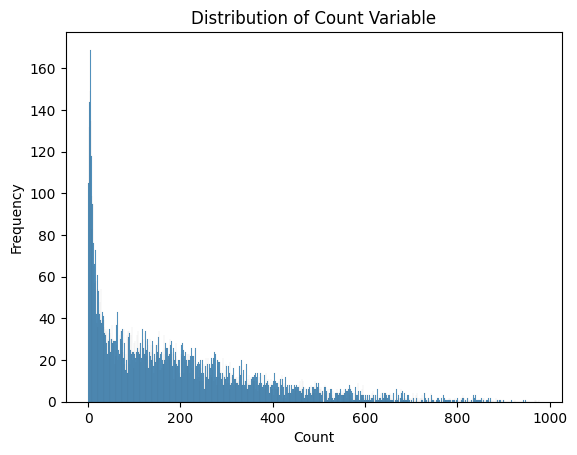

In [203]:
sns.histplot(df_cleaned['count'], bins=40, discrete=True)
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.title("Distribution of Count Variable")
plt.show()

In [204]:
print(df_cleaned['count'].describe())

# Mean and variance
print("Mean:", df_cleaned['count'].mean())
print("Variance:", df_cleaned['count'].var())

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64
Mean: 191.57413191254824
Variance: 32813.31315347235


In [205]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X, feature_names=None):
    if isinstance(X, pd.DataFrame):
        X_arr = X.values
    else:
        X_arr =np.asarray(X)
        if feature_names is None:
            feature_names = [f'x{i+1}' for i in range(X_arr.shape[1])]
            
    # drop columns that are constant / all zero
    valid_cols = []
    for i in range(X_arr.shape[1]):
        col = X_arr[:, i]
        if np.nanstd(col) == 0:
            print(f"Column {feature_names[i]} is constant and will be dropped from VIF calculation.")
        else:
            valid_cols.append(i)
        X_valid = X_arr[:, valid_cols]
        valid_names = [feature_names[i] for i in valid_cols]
        
    vif_data = pd.DataFrame()
    vif_data["feature"] = valid_names
    vif_data["VIF"] = [
        variance_inflation_factor(X_valid, i) for i in range(X_valid.shape[1])
    ]
    
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

In [206]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   weather        10886 non-null  category
 1   temp           10886 non-null  float64 
 2   atemp          10886 non-null  float64 
 3   humidity       10886 non-null  int64   
 4   windspeed      10886 non-null  float64 
 5   count          10886 non-null  int64   
 6   year           10886 non-null  int32   
 7   month          10886 non-null  int32   
 8   day            10886 non-null  int32   
 9   hour           10886 non-null  int32   
 10  weekday        10886 non-null  object  
 11  is_holiday     10886 non-null  int64   
 12  is_workingday  10886 non-null  int64   
 13  is_weekend     10886 non-null  int64   
 14  seasons        10886 non-null  object  
dtypes: category(1), float64(3), int32(4), int64(5), object(2)
memory usage: 1.0+ MB


In [207]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

def transform_data(df, target=None, test_size=0.2, random_state=RANDOM_STATE,
                   spline_cols=None, spline_df=4,spline_degree=3):
    
    if spline_cols is None:
        spline_cols = []
        
    df = df.copy()
    
    df = df.replace([np.inf, -np.inf], np.nan)
    
    
    # Separate features and target
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    if target != None and target in numeric_cols:
        numeric_cols.remove(target)
        y = df[target]
    else:
        y = None
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    #split potential spline coolumns from numeric columns
    spline_cols = [c for c in spline_cols if c in numeric_cols]
    linear_numeric_cols= [c for c in numeric_cols if c not in spline_cols]
    
    if y is not None:
        X_train_df, X_test_df, y_train, y_test = train_test_split(
                df, y, test_size=test_size, random_state=random_state
            )
    else:
        X_train_df = df
        X_test_df = df
        y_train = None
        y_test = None

    # Linear numeric preprocessing
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    # Spline preprocessing
    spline_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("spline", SplineTransformer(degree=spline_degree, n_knots=spline_df, include_bias=False)),
        ("scaler", StandardScaler())
    ])
    
    # Categorical preprocessing
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore",drop="first",))
    ])
    
    #Combine 
    transformer = [
        ("linear_numeric", numeric_transformer, linear_numeric_cols),
        ("categorical", categorical_transformer, categorical_cols),
    ]
    if spline_cols:
        transformer.append(("spline_cols", spline_transformer, spline_cols))
        
    preprocessor = ColumnTransformer(transformers=transformer)
    X_train = preprocessor.fit_transform(X_train_df)
    X_test = preprocessor.transform(X_test_df)
    
    return X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df

In [208]:
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

def run_cv_and_fit(df, target='count', families=None ,spline_cols=None, spline_df=4, spline_degree=3, n_splits=5, random_state=RANDOM_STATE):
    X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df = transform_data(
        df, target=target,spline_cols=spline_cols, spline_df=spline_df, spline_degree=spline_degree, random_state=random_state
    )
    
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []
    
    for fold, (train_idx,val_idx) in enumerate(kf.split(X_train,y_train),start=1):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        X_fold_train_sm = sm.add_constant(X_fold_train, has_constant='add')
        X_fold_val_sm = sm.add_constant(X_fold_val, has_constant='add')
        
        try:
            model = sm.GLM(y_fold_train, X_fold_train_sm, family=families).fit()
        except np.linalg.LinAlgError:
            print(f"Fold{fold}: Singular matrix encountered. Skipping this fold.")
            continue
        y_fold_pred = model.predict(X_fold_val_sm)
        
        fold_results.append({
            "Fold": fold,
            "Model":model,
            "MSE": mean_squared_error(y_fold_val, y_fold_pred),
            "MAE": mean_absolute_error(y_fold_val, y_fold_pred),
            "R2": r2_score(y_fold_val, y_fold_pred)
        })
    cv_results_df = pd.DataFrame(fold_results)
    print("\nCross-Validation Results:")
    print(cv_results_df)
    
    print("\nAverage Metrics Across Folds:")
    print(cv_results_df[['MSE', 'MAE', 'R2']].mean())
    
    # Train model now
    
    X_train_sm = sm.add_constant(X_train, has_constant='add')
    X_test_sm = sm.add_constant(X_test, has_constant='add')
    
    final_model = sm.GLM(y_train, X_train_sm, family=families).fit()
    
    y_pred = final_model.predict(X_test_sm)
    
    print("\nFinal Model Evaluation on Test Set:")
    print(f"Test MSE: {mean_squared_error(y_test, y_pred)}")
    print(f"Test MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"Test R2: {r2_score(y_test, y_pred)}")
    
    print("\nFinal Model Summary:")
    print(final_model.summary())
    
    return{
        "cv_results": cv_results_df,
        "final_model": final_model,
        "preprocessor": preprocessor,
        "X_train_df": X_train_df,
        "X_test_df": X_test_df,
        "X_train": X_train,
        "X_test": X_test,
        "X_train_const": X_train_sm,
        "X_test_const": X_test_sm,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
    }

In [209]:
results_poisson = run_cv_and_fit(df_cleaned, target='count', families=sm.families.Poisson(),  n_splits=5, random_state=RANDOM_STATE)

cv_results   = results_poisson["cv_results"]
final_model_poisson = results_poisson["final_model"]
preprocessor = results_poisson["preprocessor"]
X_train_df = results_poisson["X_train_df"]
X_test_df = results_poisson["X_test_df"]
X_train = results_poisson["X_train"]
X_test = results_poisson["X_test"]
X_train_const = results_poisson["X_train_const"]
X_test_const = results_poisson["X_test_const"]
y_train = results_poisson["y_train"]
y_test = results_poisson["y_test"]
y_pred = results_poisson["y_pred"]



Cross-Validation Results:
   Fold                                              Model           MSE  \
0     1  <statsmodels.genmod.generalized_linear_model.G...  24494.511297   
1     2  <statsmodels.genmod.generalized_linear_model.G...  23872.918634   
2     3  <statsmodels.genmod.generalized_linear_model.G...  24605.020976   
3     4  <statsmodels.genmod.generalized_linear_model.G...  24185.231776   
4     5  <statsmodels.genmod.generalized_linear_model.G...  23333.843043   

          MAE        R2  
0  114.661906  0.258620  
1  113.946879  0.243849  
2  115.886488  0.227285  
3  117.321461  0.303902  
4  114.411383  0.283824  

Average Metrics Across Folds:
MSE    24098.305145
MAE      115.245623
R2         0.263496
dtype: float64

Final Model Evaluation on Test Set:
Test MSE: 23629.186634258265
Test MAE: 113.52483130269468
Test R2: 0.2841145045733223

Final Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                

In [210]:
vif_df = calculate_vif(X_train, feature_names=preprocessor.get_feature_names_out())
print("\nVariance Inflation Factor (VIF) for each feature:")
print(vif_df)

Column linear_numeric__is_weekend is constant and will be dropped from VIF calculation.

Variance Inflation Factor (VIF) for each feature:
                                              feature        VIF
0                                linear_numeric__temp  40.439261
1                               linear_numeric__atemp  36.948776
2                       linear_numeric__is_workingday  36.036670
3                       categorical__weekday_Saturday  18.967535
4                         categorical__weekday_Sunday  18.753411
5                          linear_numeric__is_holiday   5.722299
6                         categorical__seasons_spring   4.058738
7                         categorical__seasons_winter   2.855100
8                         categorical__seasons_summer   1.914738
9                         categorical__weekday_Monday   1.800317
10                       categorical__weekday_Tuesday   1.744448
11                     categorical__weekday_Wednesday   1.739219
12              

In [211]:
final_model_poisson.pearson_chi2 / final_model_poisson.df_resid

np.float64(127.9621553174831)

In [212]:
train_pred = final_model_poisson.predict(X_train_const)
influence = final_model_poisson.get_influence()
deviance = final_model_poisson.resid_deviance
pearson_resid = final_model_poisson.resid_pearson
cooks = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:521: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / np.sqrt(1 - self.hat_matrix_diag)


In [213]:
print(len(train_pred))
print(len(deviance))
print(len(pearson_resid))
print(len(cooks))
print(len(leverage))
print(X_train_const.shape)
print(len(y_train))

8708
8708
8708
8708
8708
(8708, 20)
8708


Text(0.5, 1.0, 'Influence')

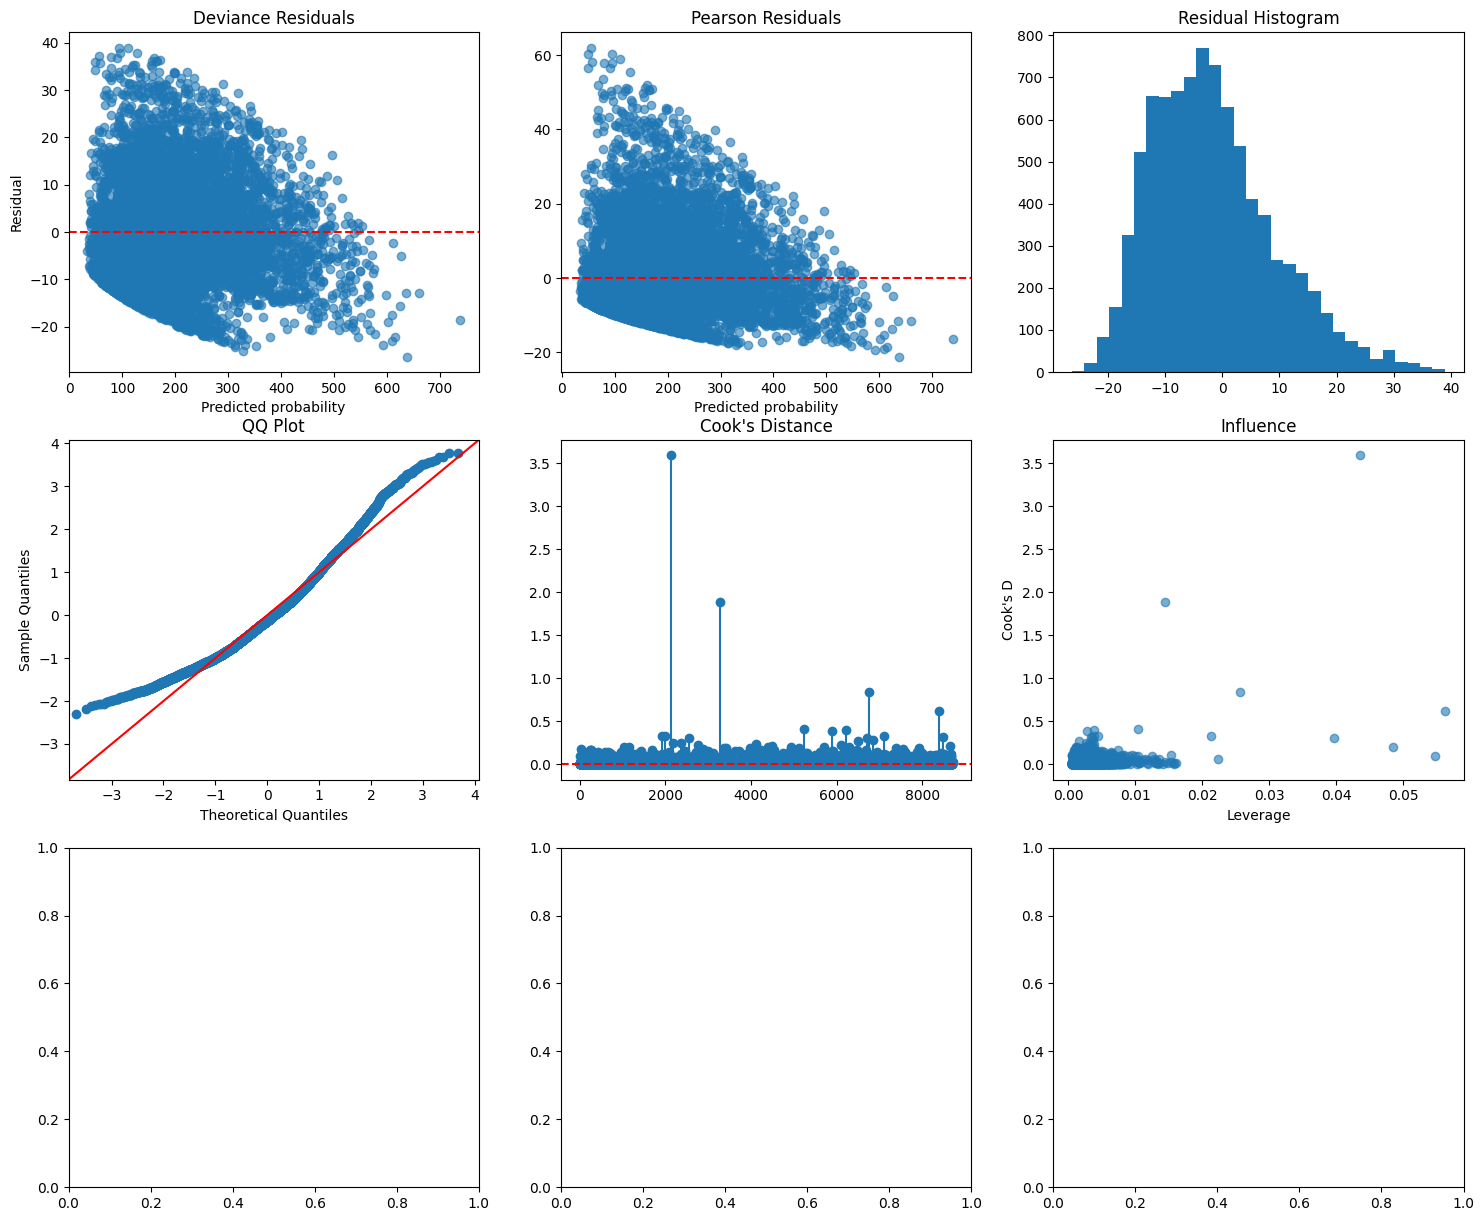

In [214]:
# ==========================================================
# DIAGNOSTIC DASHBOARD
# ==========================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# ----------------------------------------------------------
# Deviance Residuals
# ----------------------------------------------------------

axes[0,0].scatter(train_pred, deviance, alpha=0.6)
axes[0,0].axhline(0,color="red",ls="--")
axes[0,0].set_title("Deviance Residuals")
axes[0,0].set_xlabel("Predicted probability")
axes[0,0].set_ylabel("Residual")

# ----------------------------------------------------------
# Pearson Residuals
# ----------------------------------------------------------

axes[0,1].scatter(train_pred, pearson_resid, alpha=0.6)
axes[0,1].axhline(0,color="red",ls="--")
axes[0,1].set_title("Pearson Residuals")
axes[0,1].set_xlabel("Predicted probability")

# ----------------------------------------------------------
# Histogram
# ----------------------------------------------------------

axes[0,2].hist(deviance, bins=30)
axes[0,2].set_title("Residual Histogram")

# ----------------------------------------------------------
# QQ Plot
# ----------------------------------------------------------

sm.qqplot(
    deviance,
    line="45",
    fit=True,
    ax=axes[1,0]
)

axes[1,0].set_title("QQ Plot")

# ----------------------------------------------------------
# Cook's Distance
# ----------------------------------------------------------

markerline, stemlines, baseline = axes[1,1].stem(
    np.arange(len(cooks)),
    cooks,
    linefmt="C0-",
    markerfmt="C0o",
    basefmt=" "
)

axes[1,1].axhline(4/len(cooks),color="red",ls="--")
axes[1,1].set_title("Cook's Distance")

# ----------------------------------------------------------
# Leverage vs Cook
# ----------------------------------------------------------

axes[1,2].scatter(leverage,cooks,alpha=0.6)

axes[1,2].set_xlabel("Leverage")
axes[1,2].set_ylabel("Cook's D")
axes[1,2].set_title("Influence")



In [215]:
from statsmodels.nonparametric.smoothers_lowess import lowess


def per_predictor_diagnostics(model, feature_names):
# Columns you actually want to check — linear numeric + splined ones together
    linear_numeric_cols = preprocessor.named_transformers_["linear_numeric"].feature_names_in_.tolist()
    spline_cols_used = preprocessor.named_transformers_["spline"].named_steps["imputer"].feature_names_in_.tolist() \
        if "spline" in preprocessor.named_transformers_ else []

    all_continuous = linear_numeric_cols + spline_cols_used

    resid = model.resid_deviance  

    n_cols = 2
    n_rows = int(np.ceil(len(all_continuous) / n_cols))
    
    num_features = len(feature_names)
    fig, axes = plt.subplots(num_features, 1, figsize=(10, 5*num_features))
    
    if num_features == 1:
        axes = [axes]
    
    for i, feature in enumerate(all_continuous):

        x = X_train_df[feature].values  # RAW values, not the spline basis columns

        # drop rows where x is NaN (imputation happens inside the pipeline,
        # not in this raw column, so NaNs may still be here)
        mask = ~np.isnan(x)

        axes[i].scatter(x[mask], resid[mask], alpha=0.5, s=20)

        smooth = lowess(resid[mask], x[mask], frac=0.3, return_sorted=True)
        axes[i].plot(smooth[:, 0], smooth[:, 1], color="red", linewidth=2)

        axes[i].axhline(0, color="black", linestyle="--", linewidth=1)

        tag = " (spline)" if feature in spline_cols_used else ""
        axes[i].set_title(feature + tag)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Deviance Residual")

    for j in range(len(all_continuous), len(axes)):
        fig.delaxes(axes[j])

    
    plt.tight_layout()
    plt.show()

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


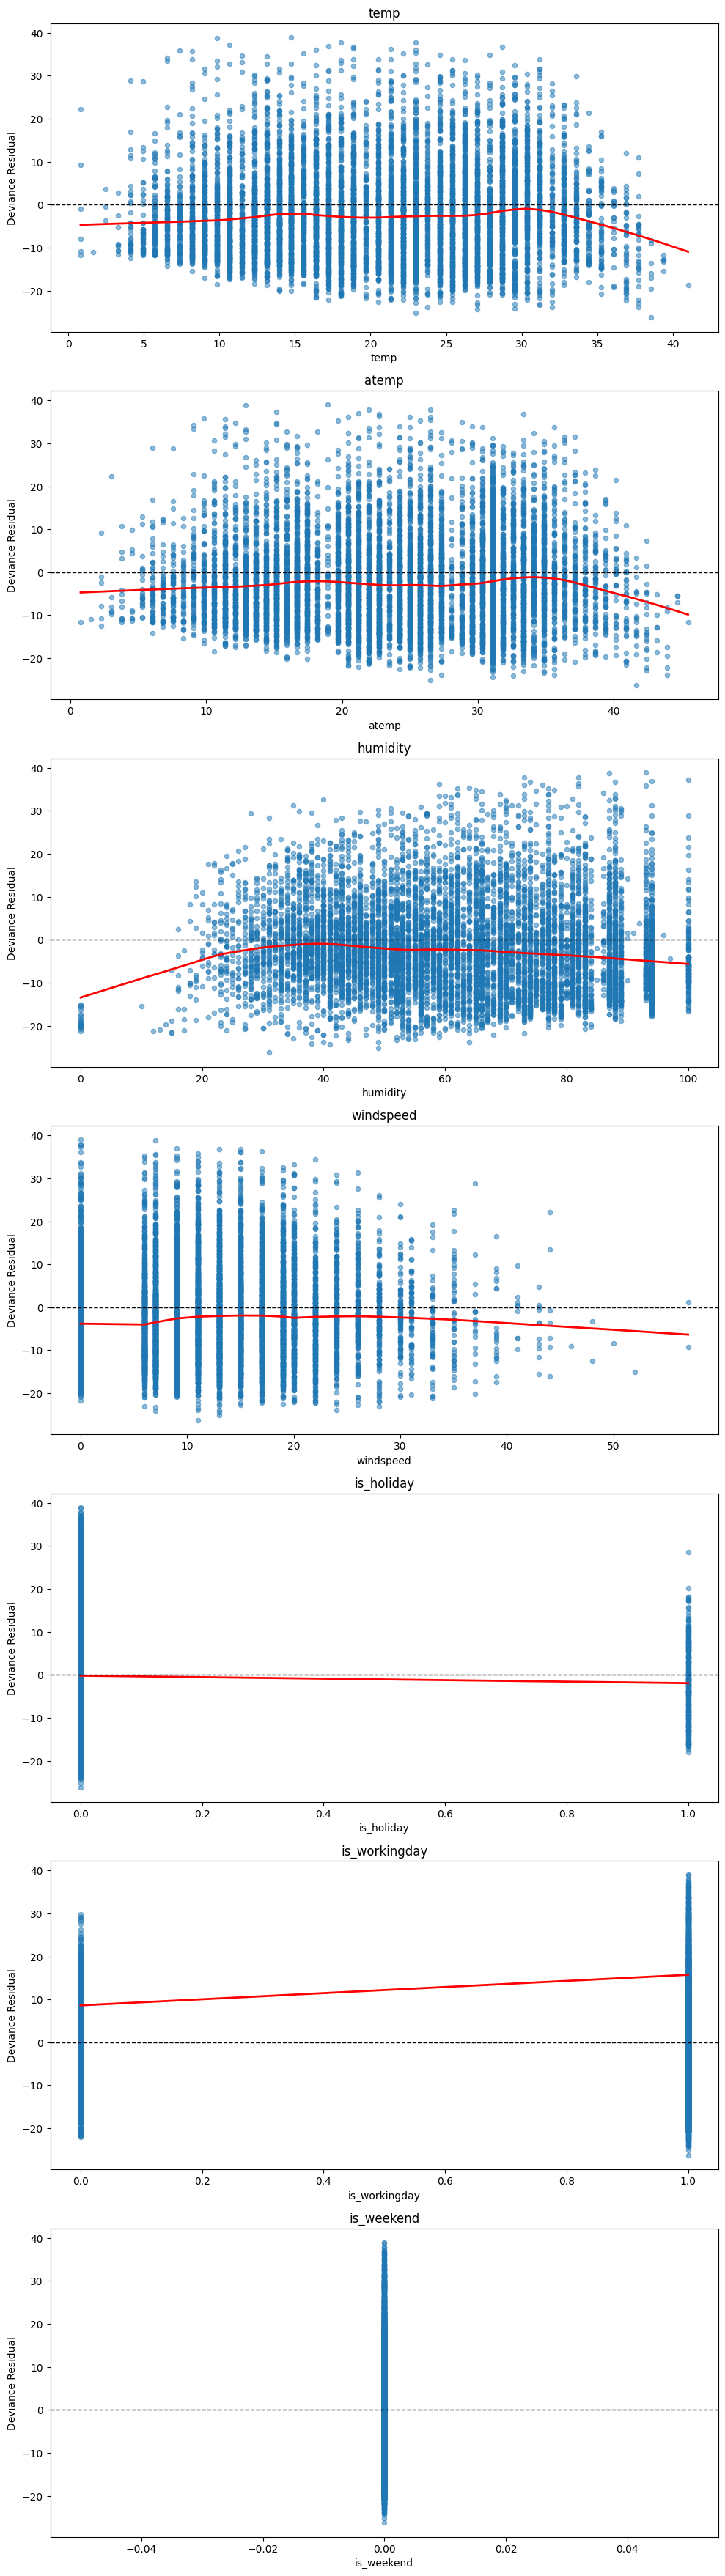

In [216]:
per_predictor_diagnostics(final_model_poisson, preprocessor.get_feature_names_out())    

In [217]:
results_nb = run_cv_and_fit(df_cleaned, target='count', families=sm.families.NegativeBinomial(),  n_splits=5, random_state=RANDOM_STATE)

cv_results_nb   = results_nb["cv_results"]
final_model_nb = results_nb["final_model"]
preprocessor_nb = results_nb["preprocessor"]
X_train_df = results_nb["X_train_df"]
X_test_df = results_nb["X_test_df"]
X_train = results_nb["X_train"]
X_test = results_nb["X_test"]
y_train = results_nb["y_train"]
y_test = results_nb["y_test"]
y_pred = results_nb["y_pred"]

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "



Cross-Validation Results:
   Fold                                              Model           MSE  \
0     1  <statsmodels.genmod.generalized_linear_model.G...  25235.687607   
1     2  <statsmodels.genmod.generalized_linear_model.G...  24870.967570   
2     3  <statsmodels.genmod.generalized_linear_model.G...  25884.113470   
3     4  <statsmodels.genmod.generalized_linear_model.G...  24855.522311   
4     5  <statsmodels.genmod.generalized_linear_model.G...  23944.595341   

          MAE        R2  
0  115.958598  0.236187  
1  116.304612  0.212236  
2  118.435427  0.187116  
3  118.623739  0.284609  
4  115.814835  0.265079  

Average Metrics Across Folds:
MSE    24958.177260
MAE      117.027442
R2         0.237045
dtype: float64

Final Model Evaluation on Test Set:
Test MSE: 24396.28448876284
Test MAE: 115.0607889500524
Test R2: 0.2608739996794056

Final Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  

In [218]:
#compare poisson and nb models 
print("Poisson Model Test MSE:", mean_squared_error(results_poisson["y_test"], results_poisson["y_pred"]),
      "Negative Binomial Model Test MSE:", mean_squared_error(results_nb["y_test"], results_nb["y_pred"]))
print("Poisson model AIC:", final_model_poisson.aic, 
      "Negative Binomial model AIC:", final_model_nb.aic)
print("Poisson model BIC:", final_model_poisson.bic,
      "Negative Binomial model BIC:", final_model_nb.bic)
print("Poisson model Pearson Chi2 / df:", final_model_poisson.pearson_chi2 / final_model_poisson.df_resid,
      "Negative Binomial model Pearson Chi2 / df:", final_model_nb.pearson_chi2 / final_model_nb.df_resid)
print("Poisson model Log-likelihood:", final_model_poisson.llf,
      "Negative Binomial model Log-likelihood:", final_model_nb.llf)
print("Poisson model Deviance:", final_model_poisson.deviance,
      "Negative Binomial model Deviance:", final_model_nb.deviance)

Poisson Model Test MSE: 23629.186634258265 Negative Binomial Model Test MSE: 24396.28448876284
Poisson model AIC: 1082329.3831975525 Negative Binomial model AIC: 106646.62930358853
Poisson model BIC: 947721.8741020283 Negative Binomial model BIC: -69325.81745374703
Poisson model Pearson Chi2 / df: 127.9621553174831 Negative Binomial model Pearson Chi2 / df: 0.8737731057337914
Poisson model Log-likelihood: -541146.6915987763 Negative Binomial model Log-likelihood: -53305.314651794266
Poisson model Deviance: 1026557.5317022884 Negative Binomial model Deviance: 9509.840146513028


c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [238]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.gam.api import GLMGam, BSplines
from pygam import s, PoissonGAM
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

def run_cv_and_fit_universal(df, target='count', framework='pygam', gam_type=None, 
                             spline_cols=None, spline_df=4, spline_degree=3, 
                             n_splits=5, random_state=42, family_type='poisson'):
    
    # 1. Transform data using your existing preprocessor
    X_train, X_test, y_train, y_test, preprocessor, X_train_df, X_test_df = transform_data(
        df, target=target, spline_cols=spline_cols, spline_df=spline_df, spline_degree=spline_degree, random_state=random_state
    )
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []
    
    # Helper for Poisson Deviance (D^2)
    def poisson_deviance(y_true, y_pred):
        y_true = np.array(y_true, dtype=float)
        y_pred = np.maximum(np.array(y_pred, dtype=float), 1e-10)
        term = np.where(y_true > 0, y_true * np.log(y_true / y_pred), 0.0)
        dev = 2.0 * np.sum(term - (y_true - y_pred))
        return dev

    def poisson_d2_score(y_true, y_pred):
        y_true = np.array(y_true, dtype=float)
        y_pred = np.maximum(np.array(y_pred, dtype=float), 1e-10)
        dev_model = poisson_deviance(y_true, y_pred)
        y_mean = np.mean(y_true)
        dev_null = poisson_deviance(y_true, np.full_like(y_true, y_mean))
        if dev_null == 0:
            return 0.0
        return 1.0 - (dev_model / dev_null)

    # Helper to handle internal modeling logic for each framework
    def _fit_and_predict(X_tr, y_tr, X_val, framework_type, fam_type):
        metrics_dict = {}
        
        if framework_type == 'pygam':
            X_tr_sm = sm.add_constant(X_tr, has_constant='add')
            X_val_sm = sm.add_constant(X_val, has_constant='add')
            terms = s(0)
            for i in range(1, X_tr_sm.shape[1]):
                terms += s(i)
            
            if gam_type is not None:
                model = gam_type(terms)
            else:
                model = PoissonGAM(terms) 
                
            lam_grid = np.logspace(-3, 3, 10)
            model.gridsearch(X_tr_sm, y_tr, lam=lam_grid)
            y_pred_val = model.predict(X_val_sm)
            
            try:
                metrics_dict['AIC'] = model.statistics_.get('AIC', np.nan)
            except Exception:
                metrics_dict['AIC'] = np.nan
            try:
                metrics_dict['LogLikelihood'] = model.statistics_.get('loglikelihood', np.nan)
            except Exception:
                metrics_dict['LogLikelihood'] = np.nan
                
            if fam_type == 'negativebinomial':
                try:
                    metrics_dict['alpha'] = model.statistics_.get('theta', np.nan)
                except Exception:
                    metrics_dict['alpha'] = np.nan
            else:
                metrics_dict['alpha'] = np.nan
                
            return model, y_pred_val, metrics_dict
            
        elif framework_type in ['statsmodels-nb', 'statsmodels']:
            num_features = X_tr.shape[1]
            
            # Compute global bounds from overall X_train to prevent out-of-bound errors in validation folds
            global_min = np.min(X_train, axis=0)
            global_max = np.max(X_train, axis=0)
            
            knot_kwds_list = [
                {'lower_bound': global_min[i], 'upper_bound': global_max[i]} 
                for i in range(num_features)
            ]

            x_splines = BSplines(
                X_tr,
                df=[spline_df] * num_features,
                degree=[spline_degree] * num_features,
                knot_kwds=knot_kwds_list
            )

            X_tr_intercept = np.ones((X_tr.shape[0], 1))
            X_val_intercept = np.ones((X_val.shape[0], 1))

            sm_family = sm.families.NegativeBinomial() if fam_type == 'negativebinomial' else sm.families.Poisson()

            model = GLMGam(
                endog=y_tr,
                exog=X_tr_intercept,
                smoother=x_splines,
                alpha=np.ones(num_features) * 1.0,
                family=sm_family
            )

            try:
                alpha_opt, _, _ = model.select_penweight(
                    criterion='aic',
                    method='nm',
                    start_params=np.zeros(num_features)
                )
            except Exception:
                best_alpha = 1.0
                best_aic = np.inf
                for a in np.logspace(-2, 4, 9):
                    try:
                        model.alpha = np.full(num_features, a)
                        res_tmp = model.fit(disp=False)
                        if res_tmp.aic < best_aic:
                            best_aic = res_tmp.aic
                            best_alpha = a
                    except Exception:
                        continue
                alpha_opt = np.full(num_features, best_alpha)

            model.alpha = alpha_opt
            results = model.fit(disp=False)

            y_pred_val = results.predict(X_val_intercept, exog_smooth=X_val)
            
            metrics_dict['AIC'] = getattr(results, 'aic', np.nan)
            metrics_dict['LogLikelihood'] = getattr(results, 'llf', np.nan)
            metrics_dict['alpha'] = getattr(results, 'scale', np.nan) if fam_type == 'negativebinomial' else np.nan
                
            return results, y_pred_val, metrics_dict

    # 2. Cross-Validation Loop
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train), start=1):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx], y_train.iloc[val_idx] if hasattr(y_train, 'iloc') else y_train[val_idx]
        
        try:
            model_obj, y_fold_pred, fold_metrics = _fit_and_predict(X_fold_train, y_fold_train, X_fold_val, framework, family_type)
        except Exception as e:
            print(f"Fold {fold}: Model failed to converge/compute. Skipping. Error: {e}")
            continue
            
        mse_val = mean_squared_error(y_fold_val, y_fold_pred)
        row = {
            "Fold": fold,
            "Model": model_obj,
            "MSE": mse_val,
            "RMSE": np.sqrt(mse_val),
            "MAE": mean_absolute_error(y_fold_val, y_fold_pred),
            "D2": poisson_d2_score(y_fold_val, y_fold_pred),
            "AIC": fold_metrics.get('AIC', np.nan),
            "LogLikelihood": fold_metrics.get('LogLikelihood', np.nan)
        }
        if family_type == 'negativebinomial':
            row["Alpha_NB"] = fold_metrics.get('alpha', np.nan)
            
        fold_results.append(row)
        
    cv_results_df = pd.DataFrame(fold_results)
    
    print("\nCross-Validation Results:")
    print(cv_results_df.drop(columns=["Model"], errors="ignore"))
    
    print("\nAverage Metrics Across Folds:")
    numeric_cols = cv_results_df.select_dtypes(include=[np.number]).columns.drop("Fold")
    print(cv_results_df[numeric_cols].mean())
    
    # 3. Train Final Model on full dataset
    print(f"\nTraining Final Model using {framework} ({family_type})...")
    final_model, y_pred, final_metrics = _fit_and_predict(X_train, y_train, X_test, framework, family_type)
    
    return {
        "cv_results": cv_results_df,
        "final_model": final_model,
        "final_metrics": final_metrics,
        "preprocessor": preprocessor,
        "X_train_df": X_train_df,
        "X_test_df": X_test_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
    }

In [227]:
from pygam import PoissonGAM

# 1. Poisson GAM using pyGAM (using PoissonGAM class directly)
results_gam = run_cv_and_fit_universal(
    df_cleaned, 
    target='count', 
    framework='pygam', 
    gam_type=PoissonGAM, 
    family_type='poisson', 
    random_state=RANDOM_STATE
)

cv_results_gam   = results_gam["cv_results"]
final_model_gam = results_gam["final_model"]
preprocessor_gam = results_gam["preprocessor"]
X_train_df = results_gam["X_train_df"]
X_test_df = results_gam["X_test_df"]
X_train = results_gam["X_train"]
X_test = results_gam["X_test"]
y_train = results_gam["y_train"]
y_test = results_gam["y_test"]
y_pred = results_gam["y_pred"]





c:\Users\takun\miniconda3\Lib\site-packages\pygam\pygam.py:2859: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = y.ravel()
  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 10% (1 of 10) |##                       | Elapsed Time: 0:00:04 ETA:   0:00:38
 20% (2 of 10) |#####                    | Elapsed Time: 0:00:05 ETA:   0:00:23
 30% (3 of 10) |#######                  | Elapsed Time: 0:00:08 ETA:   0:00:20
 40% (4 of 10) |##########               | Elapsed Time: 0:00:11 ETA:   0:00:17
 50% (5 of 10) |############             | Elapsed Time: 0:00:13 ETA:   0:00:13
 60% (6 of 10) |###############          | Elapsed Time: 0:00:16 ETA:   0:00:11
 70% (7 of 10) |#################        | Elapsed Time: 0:00:22 ETA:   0:00:09
 80% (8 of 10) |####################     | Elapsed Time: 0:00:26 ETA:   0:00:06
 90% (9 of 10) |##################


Cross-Validation Results:
   Fold           MSE          RMSE            MAE           D2  \
0     1  2.170917e+14  1.473403e+07  353132.015769 -4268.030403   
1     2  2.279880e+04  1.509927e+02     111.568808     0.290589   
2     3  2.380074e+04  1.542749e+02     113.105563     0.270423   
3     4  2.337099e+04  1.528757e+02     115.297153     0.326236   
4     5  2.255580e+04  1.501859e+02     112.269320     0.312301   

             AIC  LogLikelihood  
0  828106.320900 -413966.053006  
1  828746.089273 -414285.875955  
2  828122.324879 -413973.959122  
3  822300.658030 -411064.110814  
4  827971.722282 -413898.620352  

Average Metrics Across Folds:
MSE              4.341834e+13
RMSE             2.946928e+06
MAE              7.071685e+04
D2              -8.533662e+02
AIC              8.270494e+05
LogLikelihood   -4.134377e+05
dtype: float64

Training Final Model using pygam (poisson)...


 10% (1 of 10) |##                       | Elapsed Time: 0:00:06 ETA:   0:01:01
 20% (2 of 10) |#####                    | Elapsed Time: 0:00:08 ETA:   0:00:35
 30% (3 of 10) |#######                  | Elapsed Time: 0:00:11 ETA:   0:00:25
 40% (4 of 10) |##########               | Elapsed Time: 0:00:13 ETA:   0:00:20
 50% (5 of 10) |############             | Elapsed Time: 0:00:16 ETA:   0:00:16
 60% (6 of 10) |###############          | Elapsed Time: 0:00:19 ETA:   0:00:13
 70% (7 of 10) |#################        | Elapsed Time: 0:00:22 ETA:   0:00:09
 80% (8 of 10) |####################     | Elapsed Time: 0:00:26 ETA:   0:00:06
 90% (9 of 10) |######################   | Elapsed Time: 0:00:29 ETA:   0:00:03
100% (10 of 10) |########################| Elapsed Time: 0:00:33 Time:  0:00:33


In [228]:
final_model_gam.summary()

PoissonGAM                                                                                                
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     87.2575
Link Function:                          LogLink Log Likelihood:                               -517997.8208
Number of Samples:                         8708 AIC:                                          1036170.1567
                                                AICc:                                         1036171.9847
                                                UBRE:                                             114.5981
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3184
Feature Function                  Lam

C:\Users\takun\AppData\Local\Temp\ipykernel_11280\489482542.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  final_model_gam.summary()


In [243]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import matplotlib.pyplot as plt


def per_predictor_diagnostics_gam(model, preprocessor,type=None):

   # Columns you actually want to check — linear numeric + splined ones together
    linear_numeric_cols = preprocessor.named_transformers_["linear_numeric"].feature_names_in_.tolist()
    spline_cols_used = preprocessor.named_transformers_["spline"].named_steps["imputer"].feature_names_in_.tolist() \
        if "spline" in preprocessor.named_transformers_ else []

    all_continuous = linear_numeric_cols + spline_cols_used

    # GAM deviance residuals
    if type == 'pygam':
        resid = model.deviance_residuals(X_train, y_train)
    elif type == 'statsmodels':
        resid = model.resid_deviance


    n_cols = 2
    n_rows = int(np.ceil(len(all_continuous) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 5*n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(all_continuous):

        x = X_train_df[feature].values

        mask = ~np.isnan(x)

        axes[i].scatter(
            x[mask],
            resid[mask],
            alpha=0.5,
            s=20
        )

        smooth = lowess(
            resid[mask],
            x[mask],
            frac=0.3,
            return_sorted=True
        )

        axes[i].plot(
            smooth[:,0],
            smooth[:,1],
            color="red",
            linewidth=2
        )

        axes[i].axhline(
            0,
            color="black",
            linestyle="--"
        )

        tag = " (smooth term)" if feature in spline_cols_used else ""

        axes[i].set_title(feature + tag)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Deviance Residual")


    # remove unused plots
    for j in range(len(all_continuous), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


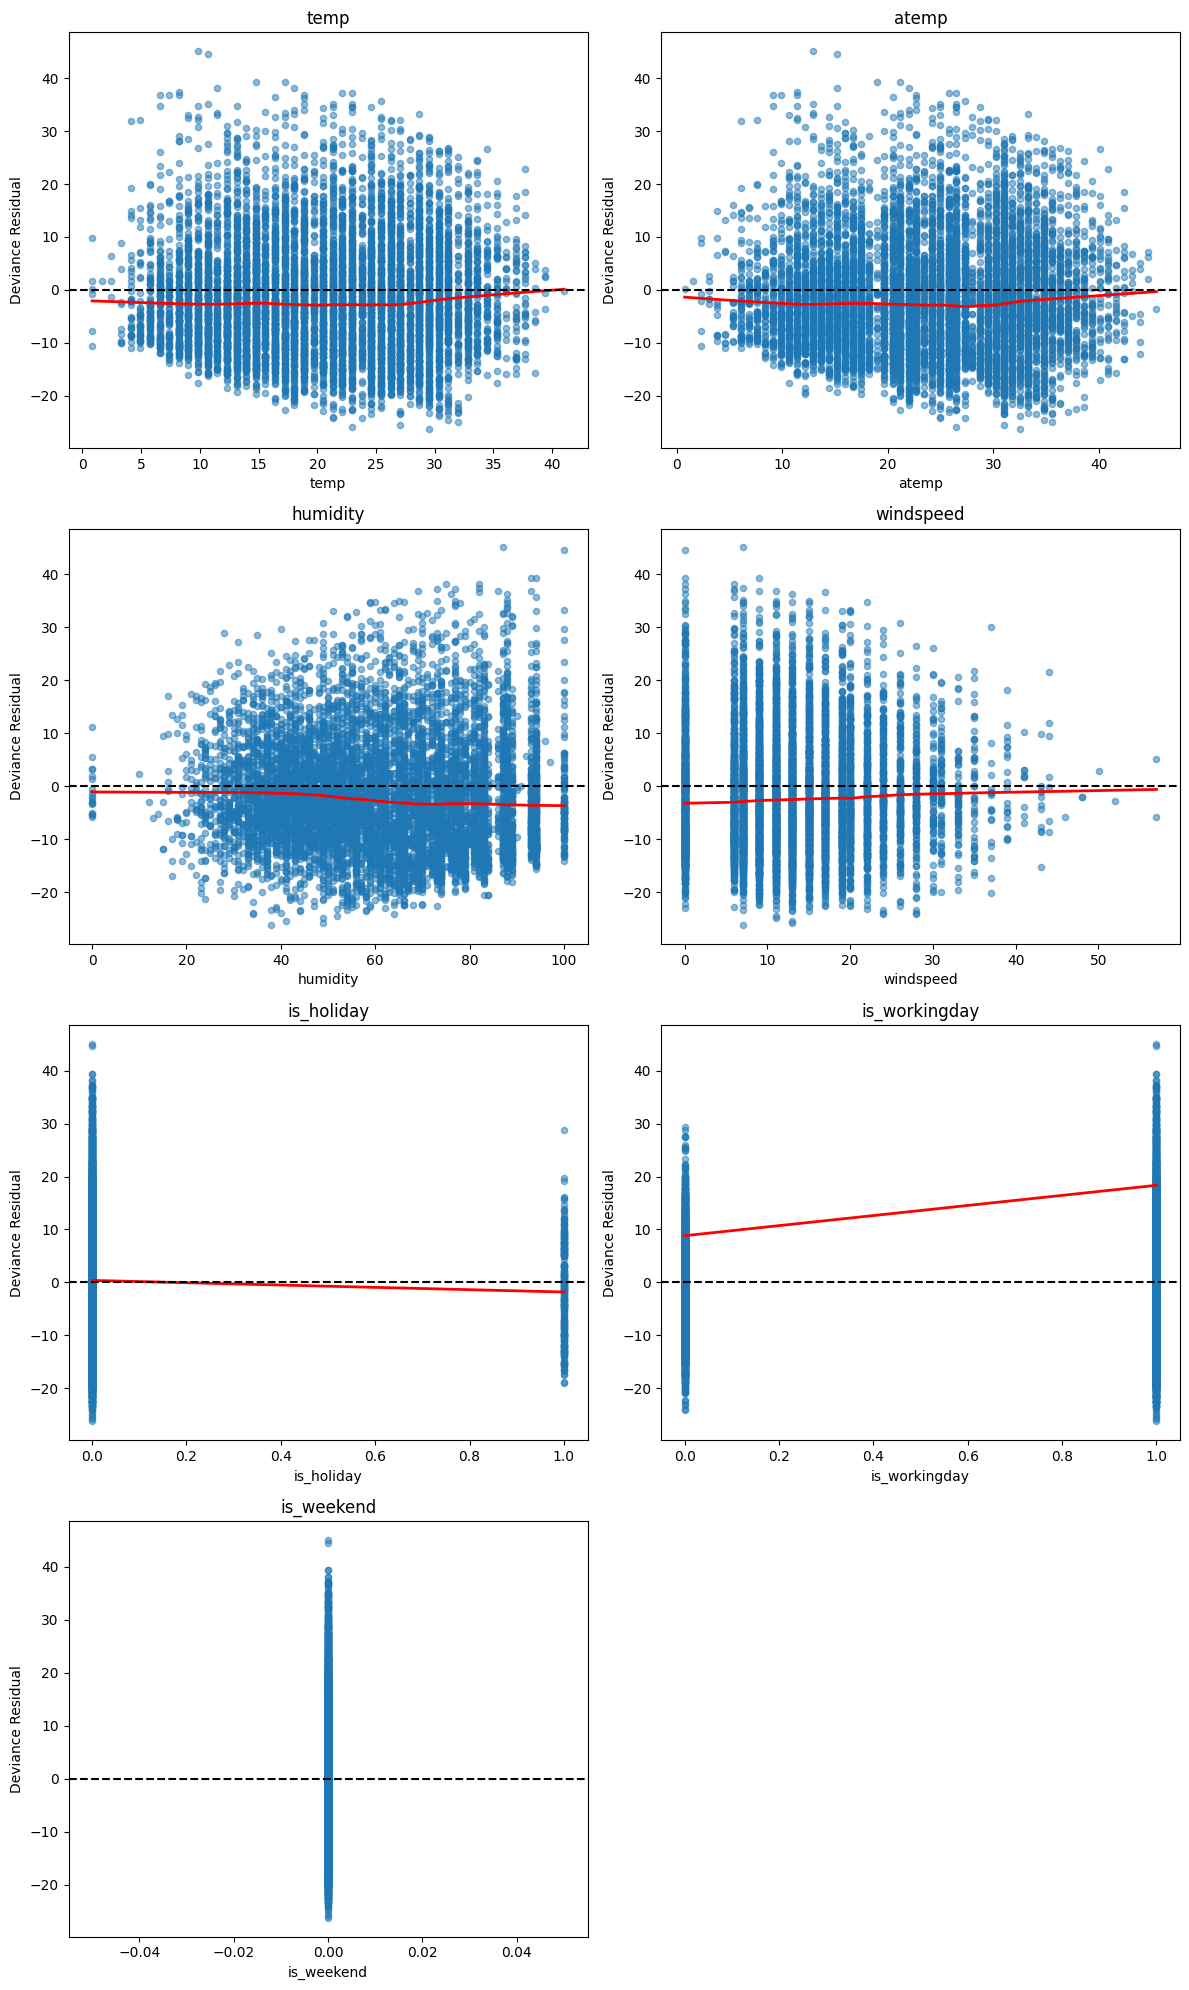

In [ ]:
per_predictor_diagnostics_gam(final_model_gam, preprocessor,type='pygam')    

In [239]:
# 2. Negative Binomial GAM using Statsmodels (GLMGam)
results_statsmodels_nb = run_cv_and_fit_universal(
    df_cleaned, 
    target='count', 
    framework='statsmodels', 
    family_type='negativebinomial', 
    random_state=RANDOM_STATE
)

cv_results_sm_nb   = results_statsmodels_nb["cv_results"]
final_model_sm_nb = results_statsmodels_nb["final_model"]
y_pred_sm_nb = results_statsmodels_nb["y_pred"]

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion pa


Cross-Validation Results:
   Fold           MSE        RMSE         MAE        D2           AIC  \
0     1  24329.134529  155.977994  114.851088  0.295192  85152.161123   
1     2  23677.067930  153.873545  114.434586  0.274462  85240.340387   
2     3  24281.640917  155.825675  115.485721  0.257836  85062.201287   
3     4  23996.136215  154.906863  116.965800  0.319107  85321.982063   
4     5  23107.504684  152.011528  113.789014  0.305902  85287.118069   

   LogLikelihood  Alpha_NB  
0  -42628.950444       1.0  
1  -42594.538309       1.0  
2  -42518.483249       1.0  
3  -42657.130728       1.0  
4  -42649.277012       1.0  

Average Metrics Across Folds:
MSE              23878.296855
RMSE               154.519121
MAE                115.105242
D2                   0.290500
AIC              85212.760586
LogLikelihood   -42609.675948
Alpha_NB             1.000000
dtype: float64

Training Final Model using statsmodels (negativebinomial)...


c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [241]:
final_model_sm_nb.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  count   No. Observations:                 8708
Model:                         GLMGam   Df Residuals:                  8682.38
Model Family:        NegativeBinomial   Df Model:                        24.62
Link Function:                    Log   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -53264.
Date:                Wed, 05 Aug 2026   Deviance:                       9428.0
Time:                        15:39:01   Pearson chi2:                 7.69e+03
No. Iterations:                    18   Pseudo R-squ. (CS):             0.2461
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4414      1.064      2.295      0.022       0.356       4.527
x0_s0         -0.9853      0.768     -1.282      0.200      -2.491       0.521
x0_s1          2.0570      0.507      4.055      0.000       1.063       3.051
x0_s2          0.3240      0.587      0.552      0.581      -0.827       1.475
x1_s0          2.4205      0.826      2.929      0.003       0.801       4.040
x1_s1          0.4967      0.505      0.984      0.325      -0.493       1.487
x1_s2          2.1218      0.588      3.606      0.000       0.969       3.275
x2_s0          1.2984      0.324      4.007      0.000       0.663       1.934
x2_s1         -0.0203      0.149     -0.136      0.892      -0.313       0.273
x2_s2         -0.5269      0.200     -2.634      0.008      -0.919      -0.135
x3_s0          0.2469      0.121      2.047      0.041       0.010       0.483
x3_s1          0.1680      0.231      0.727      0.467      -0.285       0.621
x3_s2         -0.1448      0.402     -0.360      0.718      -0.932       0.643
x4_s0          0.1095      8.061      0.014      0.989     -15.689      15.908
x4_s1          0.2191      7.679      0.029      0.977     -14.831      15.269
x4_s2          0.3286      1.045      0.314      0.753      -1.720       2.378
x5_s0          0.1665      1.781      0.093      0.926      -3.325       3.658
x5_s1          0.3330      1.799      0.185      0.853      -3.193       3.859
x5_s2          0.4995      1.044      0.478      0.632      -1.547       2.546
x6_s0       1.999e-15   3.77e-14      0.053      0.958   -7.19e-14    7.59e-14
x6_s1       -4.66e-16   8.65e-15     -0.054      0.957   -1.74e-14    1.65e-14
x6_s2       9.786e-16   1.82e-14      0.054      0.957   -3.46e-14    3.66e-14
x7_s0          0.4167      0.664      0.627      0.530      -0.885       1.719
x7_s1          0.8335      0.882      0.945      0.345      -0.895       2.562
x7_s2          1.2502      1.004      1.245      0.213      -0.718       3.219
x8_s0         -0.0242      0.574     -0.042      0.966      -1.149       1.101
x8_s1         -0.0483      0.575     -0.084      0.933      -1.175       1.078
x8_s2         -0.0725      0.046     -1.584      0.113      -0.162       0.017
x9_s0          0.0441      0.574      0.077      0.939      -1.081       1.169
x9_s1          0.0882      0.574      0.154      0.878      -1.037       1.213
x9_s2          0.1323      0.026      5.012      0.000       0.081       0.184
x10_s0        -0.0048      0.574     -0.008      0.993      -1.130       1.120
x10_s1        -0.0096      0.575     -0.017      0.987      -1.136       1.116
x10_s2        -0.0144      0.042     -0.346      0.729      -0.096       0.067
x11_s0         0.1358      0.656      0.207      0.836      -1.150       1.421
x11_s1         0.2715      0.874      0.311      0.756      -1.441       1.984
x1

c:\Users\takun\miniconda3\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


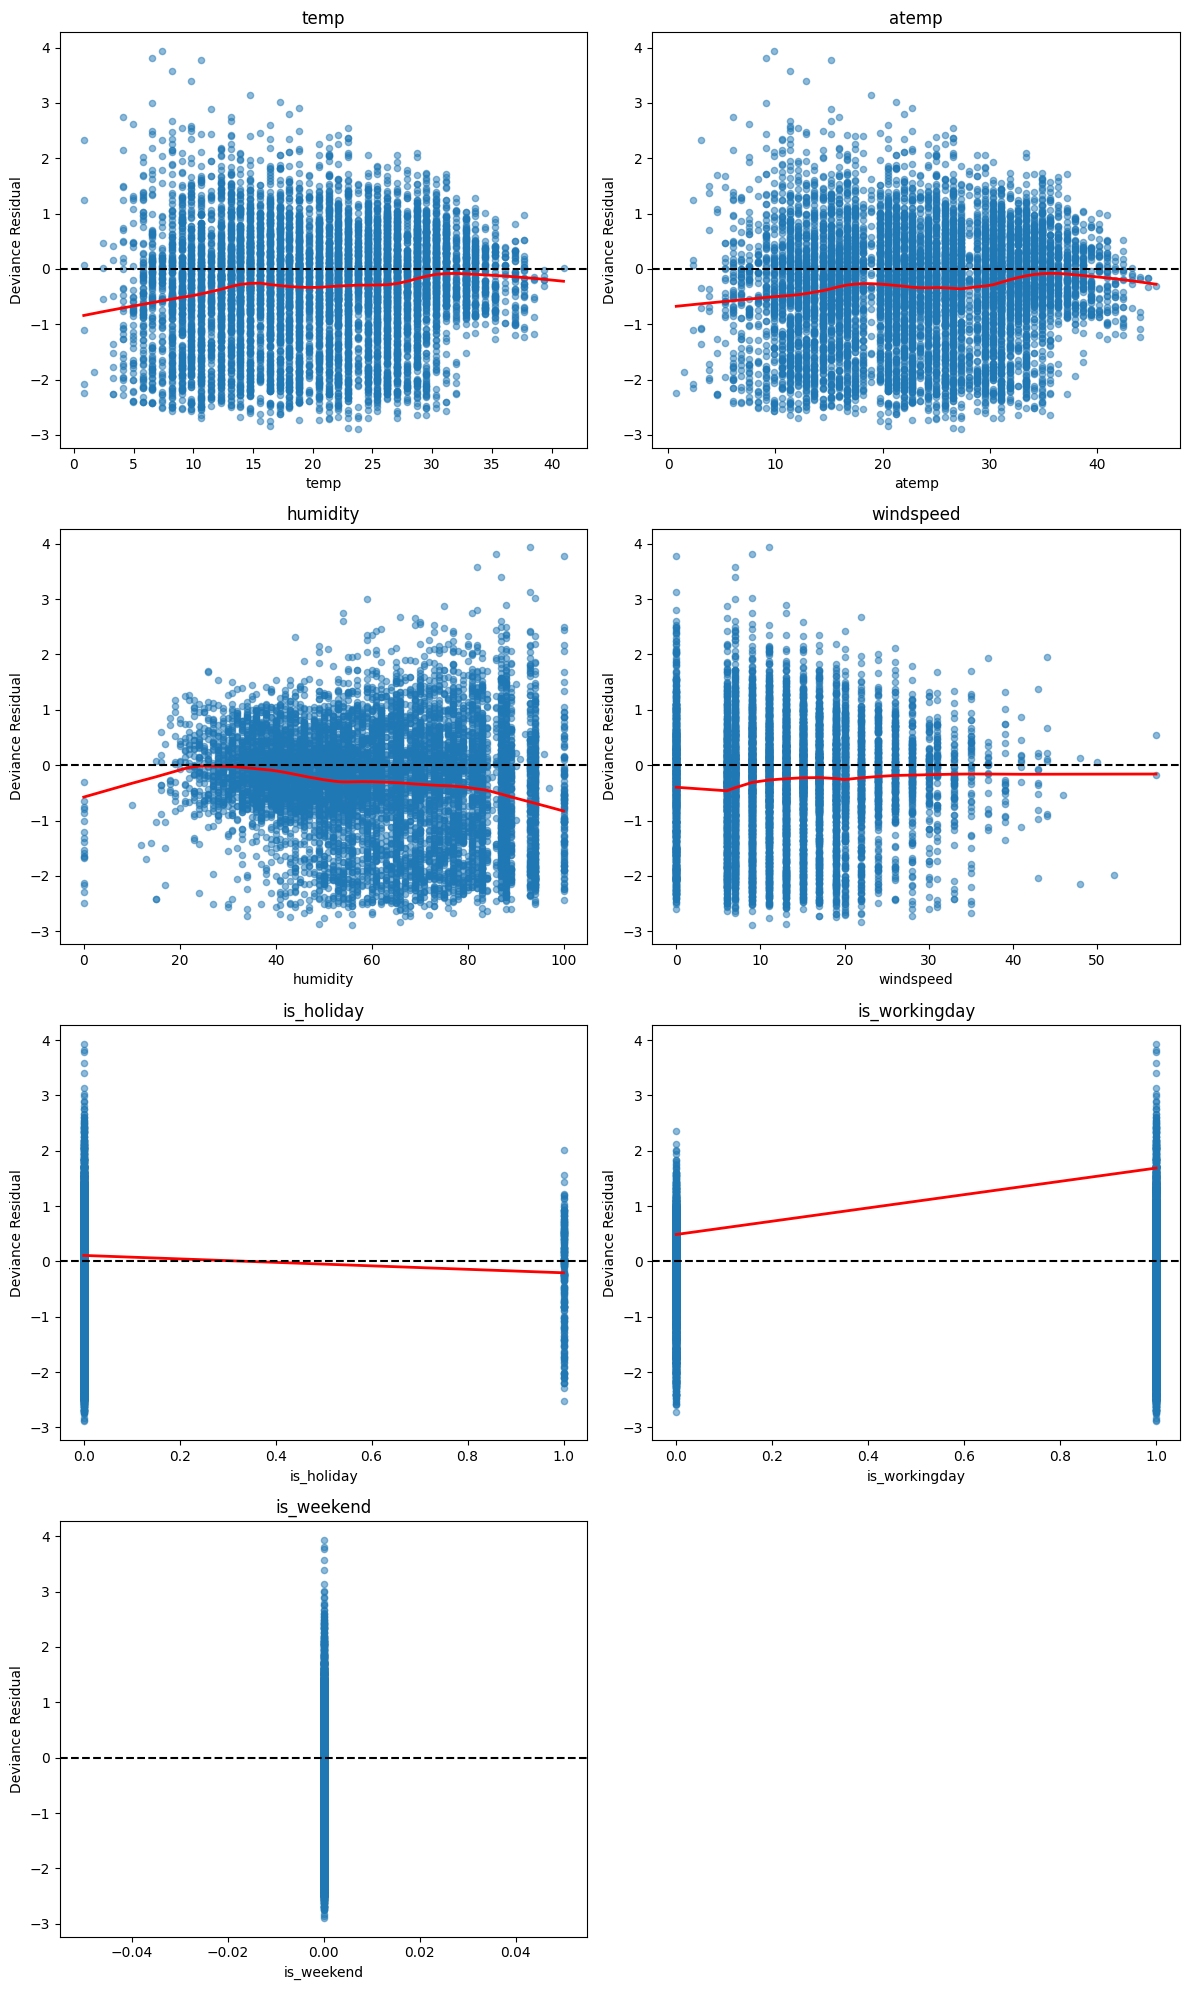

In [244]:
per_predictor_diagnostics_gam(final_model_sm_nb, preprocessor, type='statsmodels')